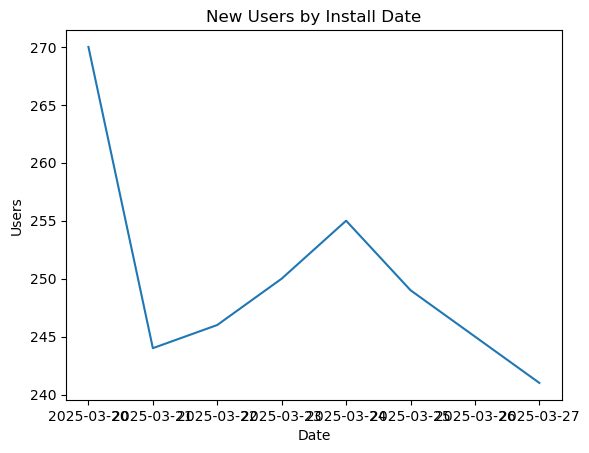

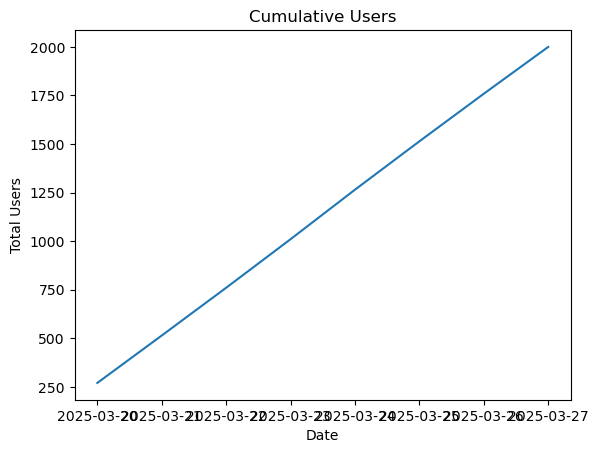

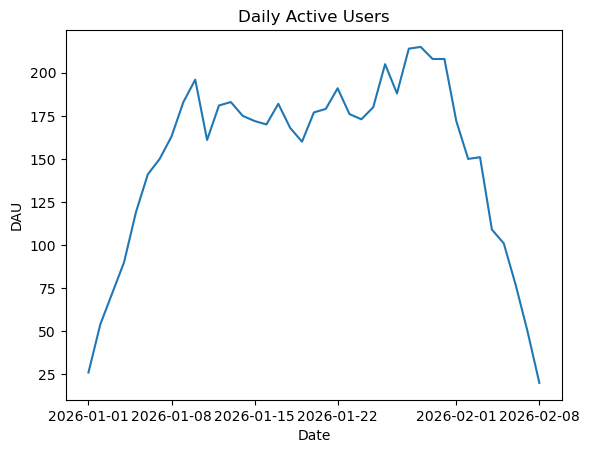

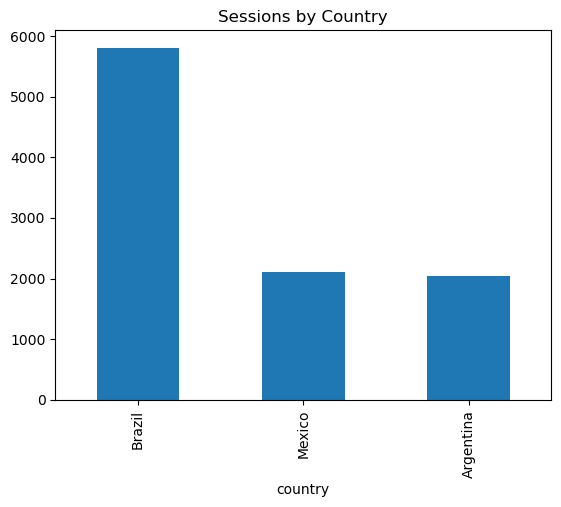

level
1     0.602544
2     0.593270
3     0.583478
4     0.576401
5     0.586176
6     0.609544
7     0.590973
8     0.590952
9     0.582752
10    0.589846
Name: fail, dtype: float64


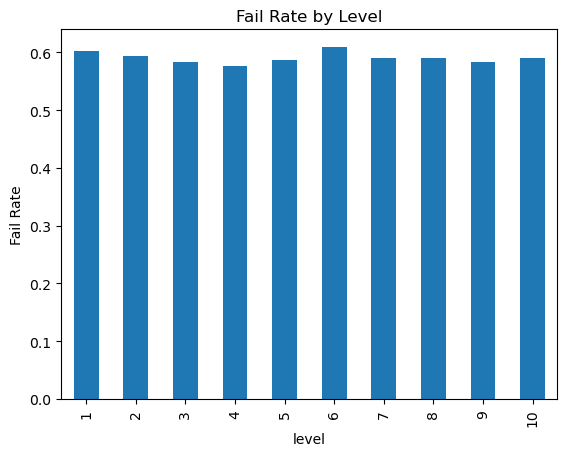

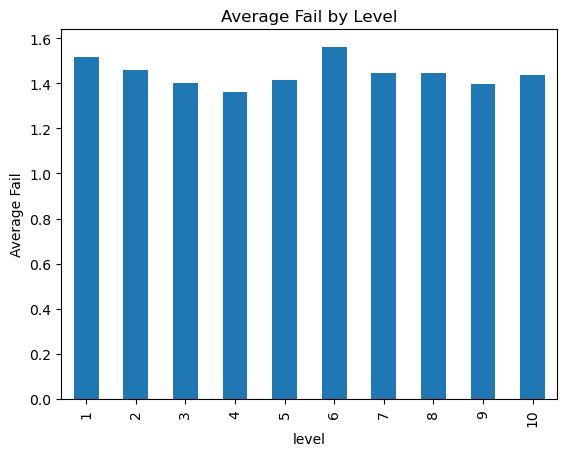

,attempts,fails,fail_rate
level,,,
6,2305,1405,0.609544
1,2516,1516,0.602544
2,2407,1428,0.593270
7,2149,1270,0.590973
8,2100,1241,0.590952
10,2009,1185,0.589846
5,2228,1306,0.586176
3,2312,1349,0.583478
9,2006,1169,0.582752


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

users = pd.read_csv("data/users.csv")
sessions = pd.read_csv("data/sessions.csv")
attempts = pd.read_csv("data/level_attempts.csv")

users["install_date"] = pd.to_datetime(users["install_date"])
sessions["session_start"] = pd.to_datetime(sessions["session_start"])
attempts["event_time"] = pd.to_datetime(attempts["event_time"])

# 1.New user 
new_users = (
    users
    .groupby("install_date")["user_id"]
    .count()
    .reset_index(name="new_users")
)
new_users
# visualize
plt.plot(new_users["install_date"], new_users["new_users"])
plt.title("New Users by Install Date")
plt.xlabel("Date")
plt.ylabel("Users")
plt.show()

# 2.Cumulative users by day
new_users["cumulative_users"] = new_users["new_users"].cumsum()
# visualize
plt.plot(new_users["install_date"], new_users["cumulative_users"])
plt.title("Cumulative Users")
plt.xlabel("Date")
plt.ylabel("Total Users")
plt.show()
# 3. Installed but never play
played_users = sessions["user_id"].unique()

never_played = users[~users["user_id"].isin(played_users)]

never_played.head()
# 4. Daily active users
sessions
sessions["session_date"] = sessions["session_start"].dt.date

dau = (
    sessions
    .groupby("session_date")["user_id"]
    .nunique()
    .reset_index(name="dau")
)
dau
#visualize 
plt.plot(dau["session_date"], dau["dau"])
plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("DAU")
plt.show()
# 5. Session by country\
sessions_country = sessions.merge(users, on="user_id")

sessions_by_country = (
    sessions_country
    .groupby("country")["session_id"]
    .count()
    .sort_values(ascending=False)
)

sessions_by_country
# visualize
sessions_by_country.plot(kind="bar")
plt.title("Sessions by Country")
plt.show()
# 6. Fail rate by level
attempts["fail"] = attempts["result"] == "fail"

fail_rate = (
    attempts
    .groupby("level")["fail"]
    .mean()
)
print(fail_rate)
fail_rate
# visualize
fail_rate.plot(kind="bar")
plt.title("Fail Rate by Level")
plt.ylabel("Fail Rate")
plt.show()
# 7. Average fail by level
user_level_fail = (
    attempts
    .assign(fail=lambda x: x["result"]=="fail")
    .groupby(["user_id","level"])["fail"]
    .sum()
    .reset_index(name="fail_count")
)
avg_fail

avg_fail = (
    user_level_fail
    .groupby("level")["fail_count"]
    .mean()
)

avg_fail
#visualize
avg_fail.plot(kind="bar")
plt.title("Average Fail by Level")
plt.ylabel("Average Fail")
plt.show()